
Cheat sheet for some of the parameters symbols
α  β  ρ  θ  ξ  δ
₀ ₁ ₂ ₃ ₄ ₅ ₆ ₇ ₈ ₉

# Thyroid Disease Modeling: Graves' & Hashimoto's
**Based on:** Kohanim et al., *"Dynamics of thyroid diseases and thyroid-axis gland masses"*

This notebook uses the dimensionless HPT axis model (`HPT_PID`) to:
1. Establish a healthy baseline
2. Simulate **Graves' disease** (AB > 0: TSH-receptor antibodies)
3. Simulate **Hashimoto's thyroiditis** (delta_H > 0: autoimmune thyrocyte destruction)
4. Demonstrate **levothyroxine treatment** for Hashimoto's (B30 > 0)
5. Show how the **PI biomolecular controller** can be conceptually connected to restore TH set-point

In [1]:
# while building the package so it refreshes modules 
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bokeh.io import output_notebook, show
import matplotlib.gridspec as gridspec
import sys, os

import biomolecular_controllers as bc
from biomolecular_controllers.model_library import DEFAULT_PARAMS, DEFAULT_INITIAL_CONDITIONS

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
models   = bc.Models()
runner   = bc.SimulationRunner()
print('Setup complete. Available models:', models.available_models)

Setup complete. Available models: ['HPT_dimensionless', 'HPT_full', 'HPT_dimensionless_PI_1', 'HPT_dimensionless_PPI', 'PC', 'PD_1', 'PD_2', 'PI_1', 'PI_2', 'PID_1', 'PID_2']


## 1. Healthy Baseline
With all disease parameters at zero, the full HPT_PID model converges to the dimensionless steady state: **x1 = x2 = x3 = T_mass = P_mass = 1**.

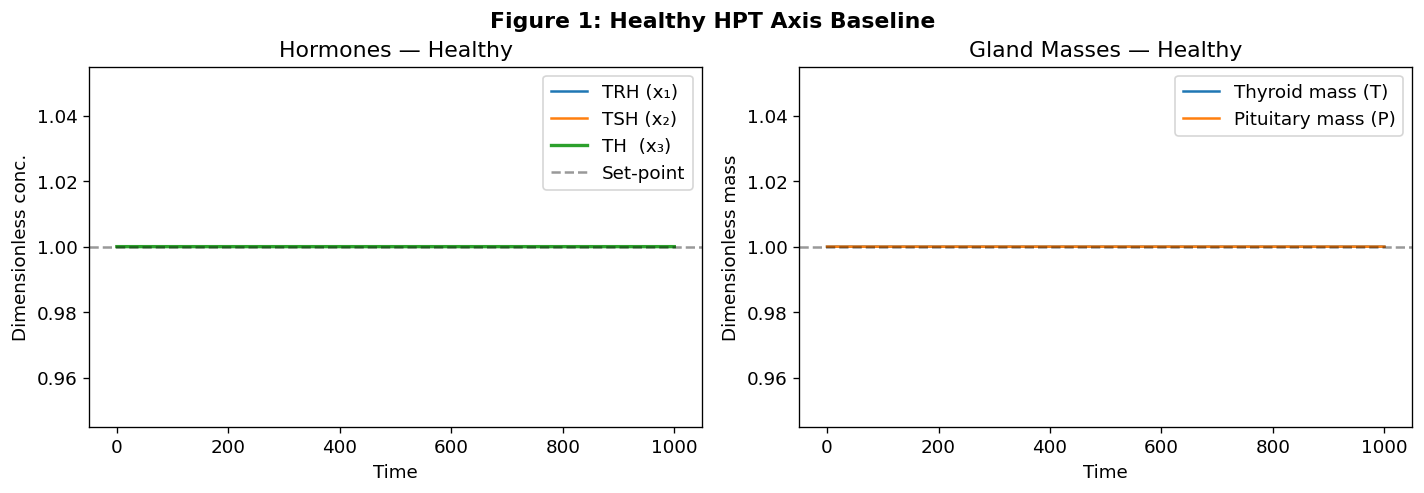

In [3]:
T_SIM   = 1000   # dimensionless time units but also 500 days)
N_PTS   = 5000
MODEL   = 'HPT_full'

t_step = 200
# perturbations = [
#     {'time': t_step, 'type': 'step', 'species': 'x3', 'value': 1.2},
# ]
#healthy = res = runner.run_with_perturbations(MODEL, t_span=(0, T_SIM), points=N_PTS, perturbations=perturbations)
healthy = res = runner.run_deterministic(MODEL, t_span=(0, T_SIM), points=N_PTS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t = healthy['time']
s = healthy['states']

axes[0].set_title('Hormones — Healthy')
axes[0].plot(t, s['x1'], label='TRH (x₁)')
axes[0].plot(t, s['x2'], label='TSH (x₂)')
axes[0].plot(t, s['x3'], label='TH  (x₃)', lw=2)
axes[0].axhline(1.0, color='k', ls='--', alpha=0.4, label='Set-point')
axes[0].set(xlabel='Time', ylabel='Dimensionless conc.')
axes[0].legend()

axes[1].set_title('Gland Masses — Healthy')
axes[1].plot(t, s['T_mass'], label='Thyroid mass (T)')
axes[1].plot(t, s['P_mass'], label='Pituitary mass (P)')
axes[1].axhline(1.0, color='k', ls='--', alpha=0.4)
axes[1].set(xlabel='Time', ylabel='Dimensionless mass')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Figure 1: Healthy HPT Axis Baseline', y=1.02, fontweight='bold')
plt.show()

## 2. Graves' Disease
**Mechanism:** TSH-receptor stimulating antibodies (AB > 0) directly stimulate the thyroid gland independently of TSH.
**Figures:** Reproducing the time-course disease / treatment trajectories and the hysteresis curve in the TSH/TH plane 

**Kohanim et al 2 step protocol**
- disease phase with AB = 5 for 100 days then treatment phase for 500 days where AB = 0 and bTH is reduced to mimic anti-thyroid drugs. also kT  = 1 and kP = 0 since pituitary has unregulated growth an
- paper describes hysteresis as a loop caused by delayed TSH equilibration after T4 normalization because P_mass atrophied over months and regrows slowly — so even after TH normalizes, TSH lags behind because there simply aren't enough thyrotrophs yet to secrete it. 

### Uncontrolled, kT/kP persist through treatment — loop doesn't close, new steady state — no recovery to baseline, recapitulates biological reality in which patients can reset to a new baseline with treatment

Subclinical: T_mass_ss=0.3926, b3_treatment=0.363869
Overt: T_mass_ss=0.8000, b3_treatment=0.178571


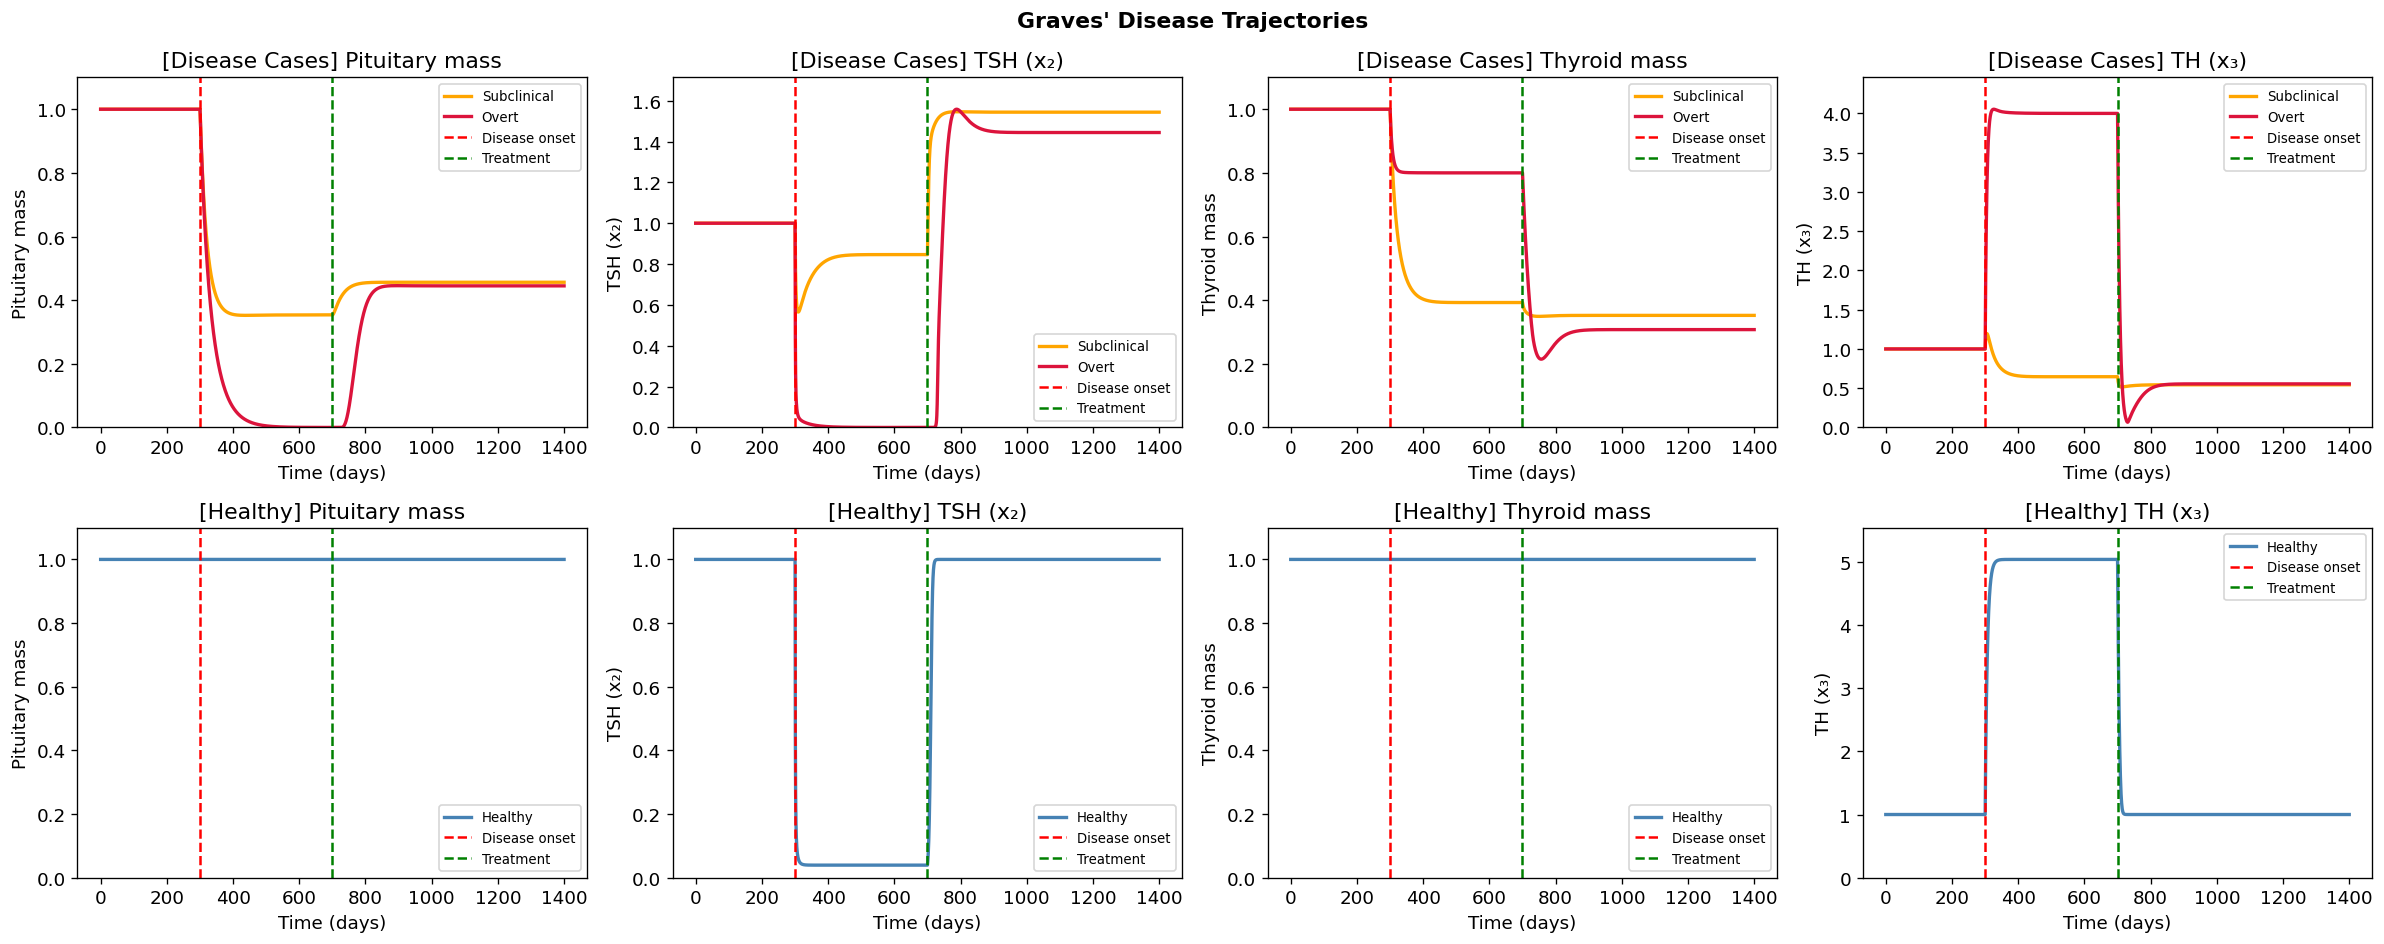

In [4]:
N_PTS   = 5000
MODEL   = 'HPT_full'

defaults = {k: float(v) for k, v in DEFAULT_PARAMS["HPT_full"].items()}

colors = {'Healthy': 'steelblue', 'Subclinical': 'orange', 'Overt': 'crimson'}
t_disease = 300.0
t_treat   = 700.0
t_recover = 1000
T_SIM     = 1400

# Calibrate b3_treatment for each disease case
# this helped show b3 reduction isn't needed in the subclinical case, pretty cool imo
b3_calibration = {}

for label, AB_val in [('Subclinical', 0.8), ('Overt', 5.0)]:
    res_disease = runner.run_with_perturbations(
        MODEL, t_span=(0, t_treat), points=N_PTS,
        perturbations=[
            {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': AB_val},
            {'time': t_disease, 'type': 'parameter', 'param': 'kT', 'value': 1.0},
            {'time': t_disease, 'type': 'parameter', 'param': 'kP', 'value': 1.0},
        ],
        params={**defaults, 'kT': 0.0, 'kP': 0.0}
    )
    
    T_ss = res_disease['states']['T_mass'][-1]
    b3_calibrated = float(defaults['a3']) / T_ss
    b3_calibration[label] = b3_calibrated
    
    print(f"{label}: T_mass_ss={T_ss:.4f}, b3_treatment={b3_calibrated:.6f}")
    
# note for healthy we don't need to change TH prod as in other disease cases because
# kP AND kT = 1e-3 to approx perfect integral feedback and kT=1 to constrain it's growth
# whereas in disease cases, carrying capacity on thyroid is what causes delay in recovery in TSH as pituitary needs to regrow
scenarios = {
    'Healthy': {'AB': 0.0, 'bT': 0.0, 'aT': 0.0, 'bP': 0.0, 'aP': 0.0, 'perts': [ # freeze thyroid & pituitary mass
        {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': 5.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'AB', 'value': 0.0},
    ]},
    'Subclinical': {'AB': 0.0, 'kT': 0.0, 'kP': 0.0, 'perts': [
        {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': 0.8},
        {'time': t_disease, 'type': 'parameter', 'param': 'kT',  'value': 1.0},
        {'time': t_disease, 'type': 'parameter', 'param': 'kP',  'value': 1.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'AB', 'value': 0.0},
        #{'time': t_treat, 'type': 'parameter', 'param': 'b3', 'value': b3_calibration['Subclinical']} ,
    ]},
    'Overt':       {'AB': 0.0, 'kT': 0.0, 'kP': 0.0, 'perts': [
        {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': 5.0},
        {'time': t_disease, 'type': 'parameter', 'param': 'kT',  'value': 1.0},
        {'time': t_disease, 'type': 'parameter', 'param': 'kP',  'value': 1.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'AB', 'value': 0.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'b3', 'value': b3_calibration['Overt']},
    ]},
}

# Run all scenarios
results = {}
for label, cfg in scenarios.items():
    if label == 'Healthy':
        params = {**defaults, 'AB': cfg['AB'], 'bT': cfg['bT'], 'bP': cfg['bP'], 'aT': cfg['aT'], 'aP': cfg['aP']}  
    else: 
        params = {**defaults, 'AB': cfg['AB'], 'kT': cfg['kT'], 'kP': cfg['kP']}
    # if label == 'Healthy':
    #     results[label] = runner.run_deterministic(
    #         MODEL, t_span=(0, T_SIM), points=N_PTS, params=params)
    # else:
    results[label] = runner.run_with_perturbations(
        MODEL, t_span=(0, T_SIM), points=N_PTS,
        perturbations=cfg['perts'], params=params
    )

# Time series, 4 subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
variables = [('P_mass', 'Pituitary mass'), ('x2', 'TSH (x₂)'), ('T_mass', 'Thyroid mass'), ('x3', 'TH (x₃)')]

disease_cases = {k: v for k, v in results.items() if k != 'Healthy'}
healthy_case  = {'Healthy': results['Healthy']}
row_data      = [disease_cases, healthy_case]
row_labels    = ['Disease Cases', 'Healthy']

for row, (case_results, row_label) in enumerate(zip(row_data, row_labels)):
    for col, (ax, (var, ylabel)) in enumerate(zip(axes[row], variables)):
        for label, res in case_results.items():
            t, s = res['time'], res['states']
            ax.plot(t, s[var], color=colors[label], lw=2, label=label)
        ax.axvline(t_disease, color='red',   ls='--', lw=1.5, label='Disease onset')
        ax.axvline(t_treat,   color='green', ls='--', lw=1.5, label='Treatment')
        ax.set(xlabel='Time (days)', ylabel=ylabel, title=f'[{row_label}] {ylabel}')
        ax.legend(fontsize=8)

        # Per-row autoscaling
        vals = np.concatenate([r['states'][var] for r in case_results.values()])
        axes[row][col].set_ylim(0, vals.max() * 1.1)

plt.suptitle("Graves' Disease Trajectories", fontweight='bold')
plt.tight_layout()
plt.show()


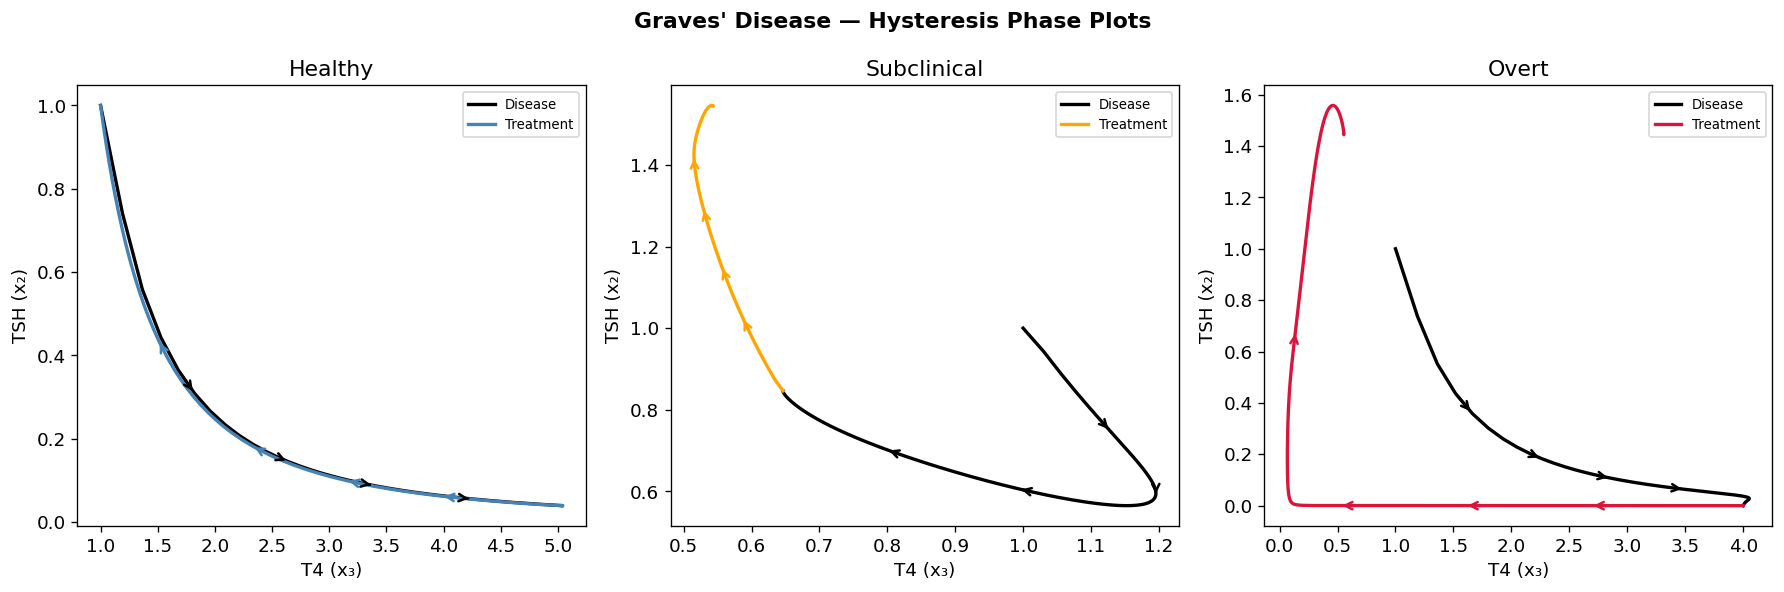

In [5]:
def add_arrows(ax, x, y, n_arrows=4, color='black'):
    # Compute cumulative arc length along trajectory
    dx = np.diff(x)
    dy = np.diff(y)
    seg_lengths = np.sqrt(dx**2 + dy**2)
    arc_length  = np.concatenate([[0], np.cumsum(seg_lengths)])
    
    # Place arrows at evenly spaced arc length positions
    arrow_positions = np.linspace(0, arc_length[-1], n_arrows + 2)[1:-1]  # exclude endpoints
    indices = [np.searchsorted(arc_length, pos) for pos in arrow_positions]
    
    for i in indices:
        if i < len(x) - 1:
            ax.annotate('',
                xytext=(x[i], y[i]),
                xy=(x[i+1], y[i+1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
            )
        
# Phase plots, 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, res) in zip(axes, results.items()):
    t, s = res['time'], res['states']
    disease_idx = (t >= t_disease) & (t < t_treat)
    treat_idx   = t >= t_treat

    # if label == 'Healthy':
    #     ax.plot(s['x3'], s['x2'], color=colors[label], lw=2, label='Baseline')
    #     ax.legend(fontsize=8)
    # else:
    ax.plot(s['x3'][disease_idx], s['x2'][disease_idx], 'k-', lw=2, label='Disease')
    ax.plot(s['x3'][treat_idx],   s['x2'][treat_idx],   color=colors[label], lw=2, label='Treatment')
    add_arrows(ax, s['x3'][disease_idx], s['x2'][disease_idx], color='black')
    add_arrows(ax, s['x3'][treat_idx],   s['x2'][treat_idx],   color=colors[label])
    ax.legend(fontsize=8)

    ax.set(xlabel='T4 (x₃)', ylabel='TSH (x₂)', title=label)
    ax.legend(fontsize=8)

plt.suptitle("Graves' Disease — Hysteresis Phase Plots", fontweight='bold')
plt.tight_layout()
plt.show()

### Uncontrolled, kT/kP restored at treatment — loop closes back to (1,1), but only because the carrying capacities are artificially reset  — ideal/desired controller dynamics

Subclinical: T_mass_ss=0.3926, b3_treatment=0.363869
Overt: T_mass_ss=0.8000, b3_treatment=0.178571


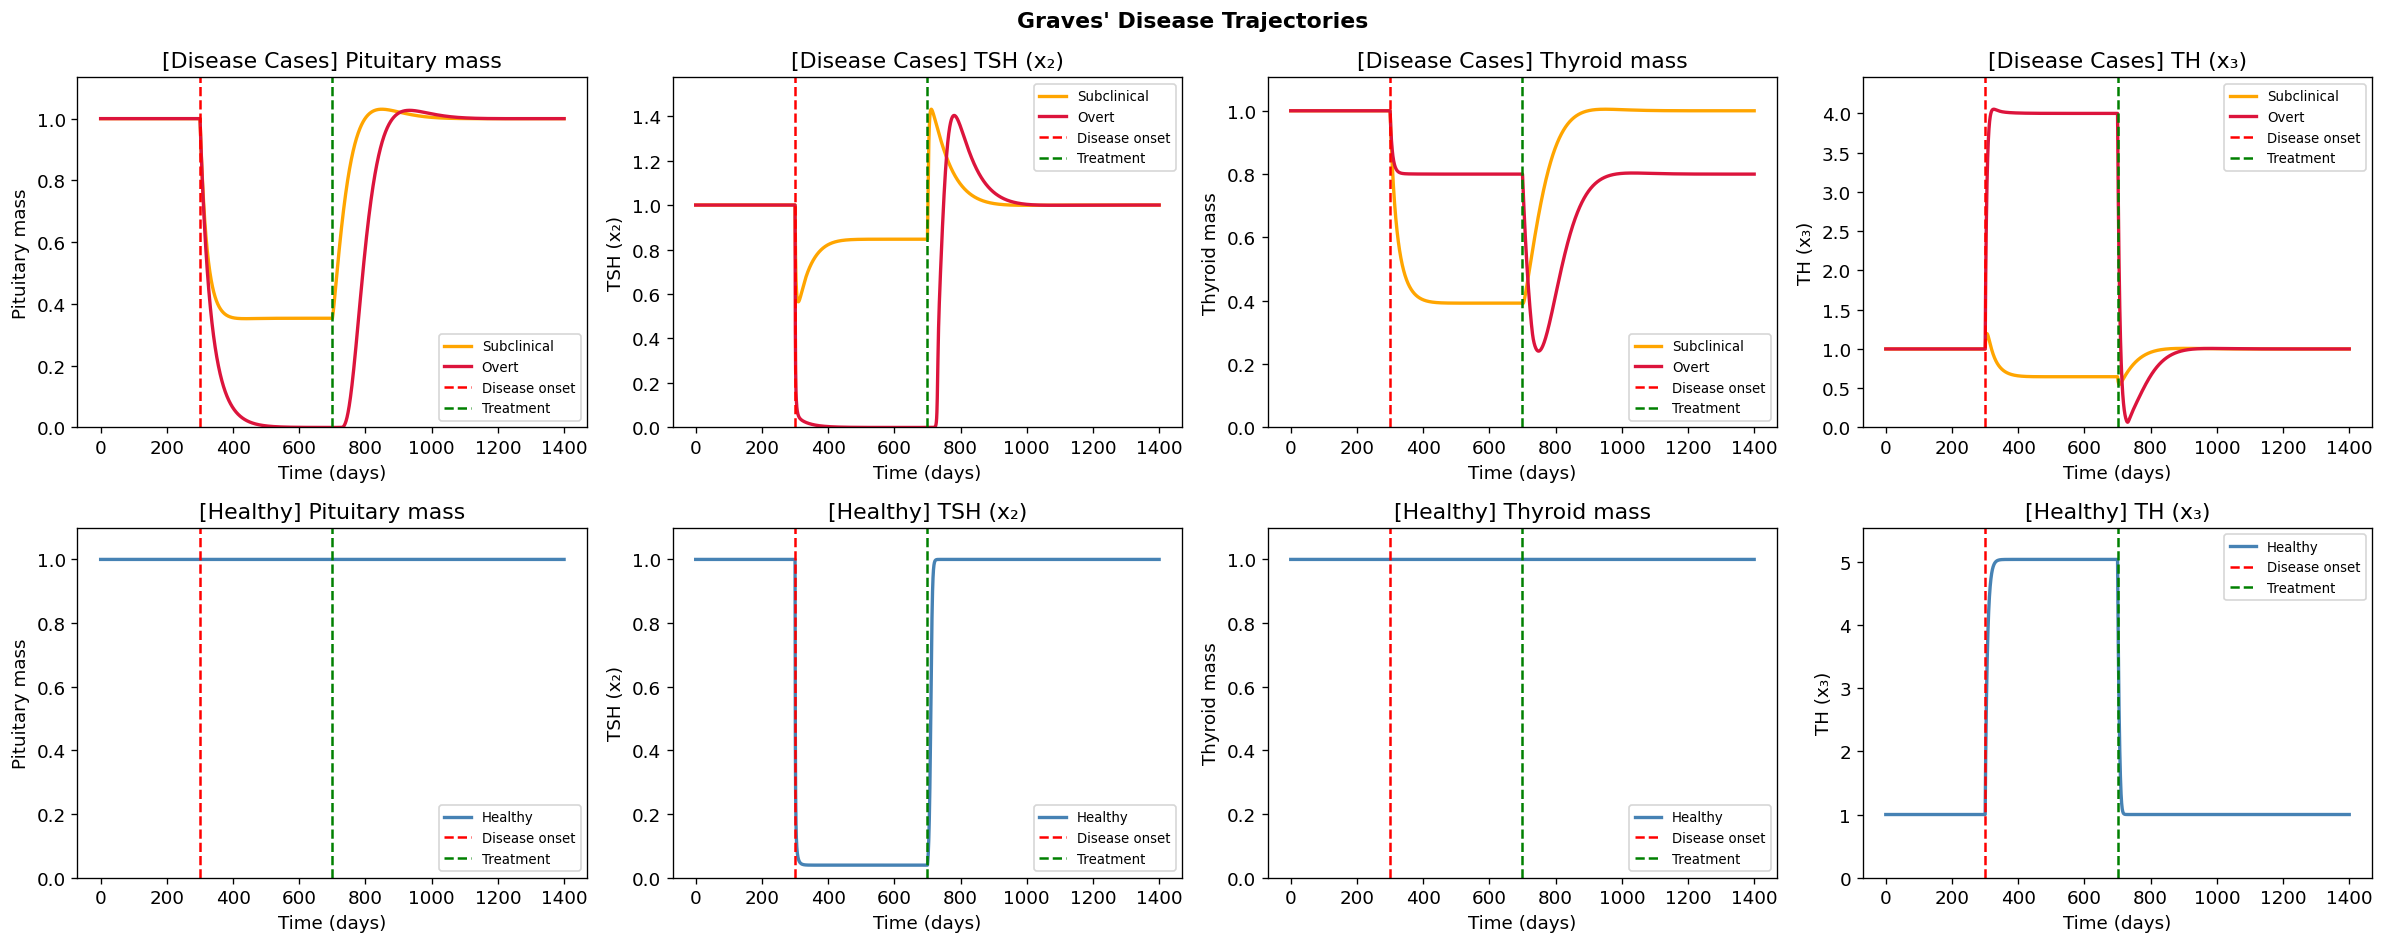

In [4]:
N_PTS   = 5000
MODEL   = 'HPT_full'

defaults = {k: float(v) for k, v in DEFAULT_PARAMS["HPT_full"].items()}

colors = {'Healthy': 'steelblue', 'Subclinical': 'orange', 'Overt': 'crimson'}
t_disease = 300.0
t_treat   = 700.0
t_recover = 1000
T_SIM     = 1400

# Calibrate b3_treatment for each disease case
# this helped show b3 reduction isn't needed in the subclinical case, pretty cool imo
b3_calibration = {}

for label, AB_val in [('Subclinical', 0.8), ('Overt', 5.0)]:
    res_disease = runner.run_with_perturbations(
        MODEL, t_span=(0, t_treat), points=N_PTS,
        perturbations=[
            {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': AB_val},
            {'time': t_disease, 'type': 'parameter', 'param': 'kT', 'value': 1.0},
            {'time': t_disease, 'type': 'parameter', 'param': 'kP', 'value': 1.0},
        ],
        params={**defaults, 'kT': 0.0, 'kP': 0.0}
    )
    
    T_ss = res_disease['states']['T_mass'][-1]
    b3_calibrated = float(defaults['a3']) / T_ss
    b3_calibration[label] = b3_calibrated
    
    print(f"{label}: T_mass_ss={T_ss:.4f}, b3_treatment={b3_calibrated:.6f}")
    
# note for healthy we don't need to change TH prod as in other disease cases because
# kP AND kT = 1e-3 to approx perfect integral feedback and kT=1 to constrain it's growth
# whereas in disease cases, carrying capacity on thyroid is what causes delay in recovery in TSH as pituitary needs to regrow
scenarios = {
    'Healthy': {'AB': 0.0, 'bT': 0.0, 'aT': 0.0, 'bP': 0.0, 'aP': 0.0, 'perts': [ # freeze thyroid & pituitary mass
        {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': 5.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'AB', 'value': 0.0},
    ]},
    'Subclinical': {'AB': 0.0, 'kT': 0.0, 'kP': 0.0, 'perts': [
        {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': 0.8},
        {'time': t_disease, 'type': 'parameter', 'param': 'kT',  'value': 1.0},
        {'time': t_disease, 'type': 'parameter', 'param': 'kP',  'value': 1.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'AB', 'value': 0.0},
        {'time': t_treat,   'type': 'parameter', 'param': 'kT', 'value': 0.0},
        {'time': t_treat,   'type': 'parameter', 'param': 'kP', 'value': 0.0},
        #{'time': t_treat, 'type': 'parameter', 'param': 'b3', 'value': b3_calibration['Subclinical']},
    ]},
    'Overt':       {'AB': 0.0, 'kT': 0.0, 'kP': 0.0, 'perts': [
        {'time': t_disease, 'type': 'parameter', 'param': 'AB', 'value': 5.0},
        {'time': t_disease, 'type': 'parameter', 'param': 'kT',  'value': 1.0},
        {'time': t_disease, 'type': 'parameter', 'param': 'kP',  'value': 1.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'AB', 'value': 0.0},
        {'time': t_treat,   'type': 'parameter', 'param': 'kT', 'value': 0.0},
        {'time': t_treat,   'type': 'parameter', 'param': 'kP', 'value': 0.0},
        {'time': t_treat, 'type': 'parameter', 'param': 'b3', 'value': b3_calibration['Overt']},
    ]},
}


# Run all scenarios
results = {}
for label, cfg in scenarios.items():
    if label == 'Healthy':
        params = {**defaults, 'AB': cfg['AB'], 'bT': cfg['bT'], 'bP': cfg['bP'], 'aT': cfg['aT'], 'aP': cfg['aP']}  
    else: 
        params = {**defaults, 'AB': cfg['AB'], 'kT': cfg['kT'], 'kP': cfg['kP']}
    # if label == 'Healthy':
    #     results[label] = runner.run_deterministic(
    #         MODEL, t_span=(0, T_SIM), points=N_PTS, params=params)
    # else:
    results[label] = runner.run_with_perturbations(
        MODEL, t_span=(0, T_SIM), points=N_PTS,
        perturbations=cfg['perts'], params=params
    )

# Time series, 4 subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
variables = [('P_mass', 'Pituitary mass'), ('x2', 'TSH (x₂)'), ('T_mass', 'Thyroid mass'), ('x3', 'TH (x₃)')]

disease_cases = {k: v for k, v in results.items() if k != 'Healthy'}
healthy_case  = {'Healthy': results['Healthy']}
row_data      = [disease_cases, healthy_case]
row_labels    = ['Disease Cases', 'Healthy']

for row, (case_results, row_label) in enumerate(zip(row_data, row_labels)):
    for col, (ax, (var, ylabel)) in enumerate(zip(axes[row], variables)):
        for label, res in case_results.items():
            t, s = res['time'], res['states']
            ax.plot(t, s[var], color=colors[label], lw=2, label=label)
        ax.axvline(t_disease, color='red',   ls='--', lw=1.5, label='Disease onset')
        ax.axvline(t_treat,   color='green', ls='--', lw=1.5, label='Treatment')
        ax.set(xlabel='Time (days)', ylabel=ylabel, title=f'[{row_label}] {ylabel}')
        ax.legend(fontsize=8)

        # Per-row autoscaling
        vals = np.concatenate([r['states'][var] for r in case_results.values()])
        axes[row][col].set_ylim(0, vals.max() * 1.1)

plt.suptitle("Graves' Disease Trajectories", fontweight='bold')
plt.tight_layout()
plt.show()


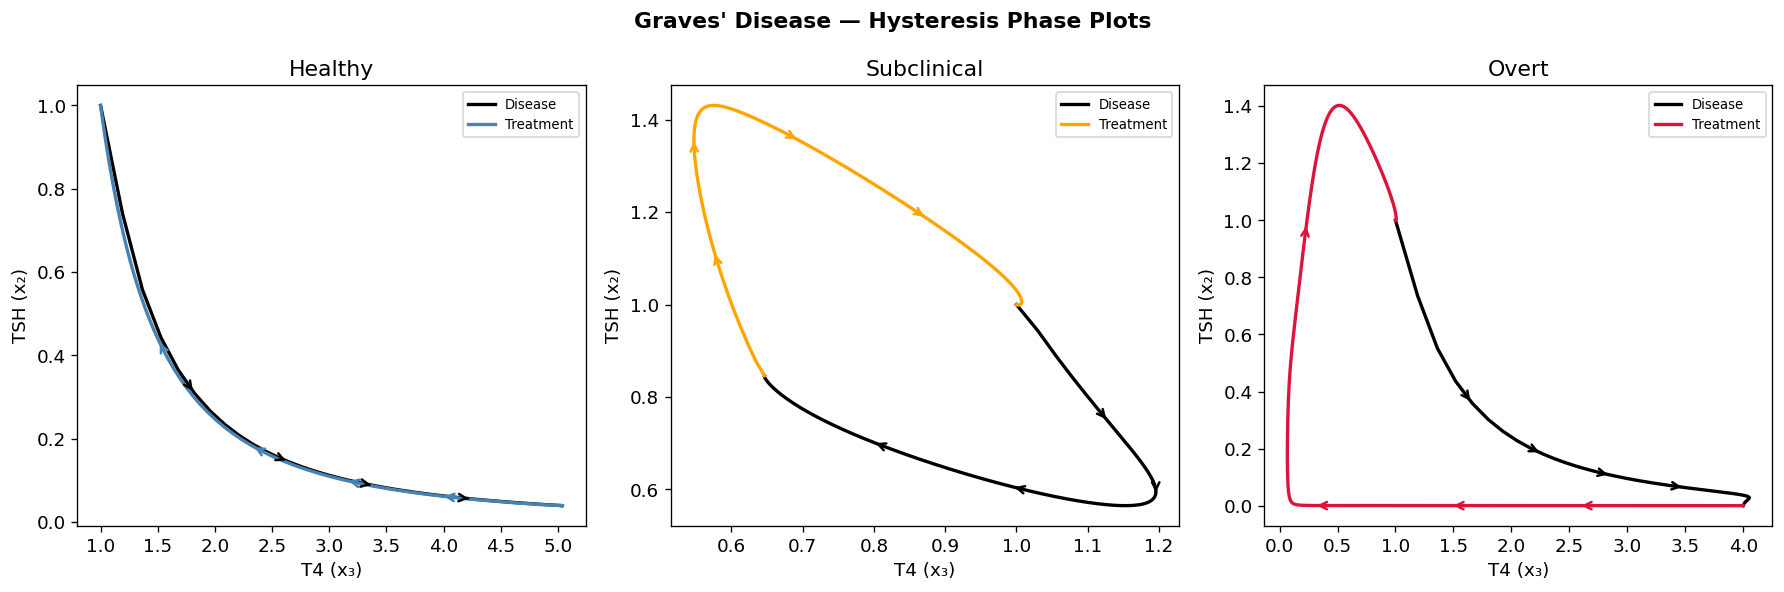

In [5]:
def add_arrows(ax, x, y, n_arrows=4, color='black'):
    # Compute cumulative arc length along trajectory
    dx = np.diff(x)
    dy = np.diff(y)
    seg_lengths = np.sqrt(dx**2 + dy**2)
    arc_length  = np.concatenate([[0], np.cumsum(seg_lengths)])
    
    # Place arrows at evenly spaced arc length positions
    arrow_positions = np.linspace(0, arc_length[-1], n_arrows + 2)[1:-1]  # exclude endpoints
    indices = [np.searchsorted(arc_length, pos) for pos in arrow_positions]
    
    for i in indices:
        if i < len(x) - 1:
            ax.annotate('',
                xytext=(x[i], y[i]),
                xy=(x[i+1], y[i+1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
            )
        
# Phase plots, 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, res) in zip(axes, results.items()):
    t, s = res['time'], res['states']
    disease_idx = (t >= t_disease) & (t < t_treat)
    treat_idx   = t >= t_treat

    # if label == 'Healthy':
    #     ax.plot(s['x3'], s['x2'], color=colors[label], lw=2, label='Baseline')
    #     ax.legend(fontsize=8)
    # else:
    ax.plot(s['x3'][disease_idx], s['x2'][disease_idx], 'k-', lw=2, label='Disease')
    ax.plot(s['x3'][treat_idx],   s['x2'][treat_idx],   color=colors[label], lw=2, label='Treatment')
    add_arrows(ax, s['x3'][disease_idx], s['x2'][disease_idx], color='black')
    add_arrows(ax, s['x3'][treat_idx],   s['x2'][treat_idx],   color=colors[label])
    ax.legend(fontsize=8)

    ax.set(xlabel='T4 (x₃)', ylabel='TSH (x₂)', title=label)
    ax.legend(fontsize=8)

plt.suptitle("Graves' Disease — Hysteresis Phase Plots", fontweight='bold')
plt.tight_layout()
plt.show()

## Figuring out what is going on with the integration of both models 

theta_1: 0.0100
u1_ss:   0.3333
w_ss:    0.0111  (target: 0.0 — no TSH supplement needed at healthy SS)
=== HPT timescales ===
TRH (x1):   0.0 days
TSH (x2):   0.0 days
TH  (x3):   7.0 days
T_mass:     30.0 days
P_mass:     30.0 days

=== Controller timescales ===
u1/u2/w:    3.3 days
q1/q2:      3.3 days

=== Baseline final values ===
x3:     1.0000  (target: 1.0)
x2:     1.0000  (target: 1.0)
w:      0.0011   (target: 0.0 — no supplement at healthy SS)
T_mass: 1.0000  (target: 1.0)
P_mass: 1.0000  (target: 1.0)

=== Equilibrated ICs ===
  x1: 1.0000
  x2: 1.0000
  x3: 1.0000
  T_mass: 1.0000
  P_mass: 1.0000
  u_1: 0.0332
  u_2: 0.0332
  c: 0.3668
  q_1: 0.0667
  q_2: 0.0667
  w: 0.0011


C:\Users\natha\AppData\Local\Temp\ipykernel_13796\326506879.py:73: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



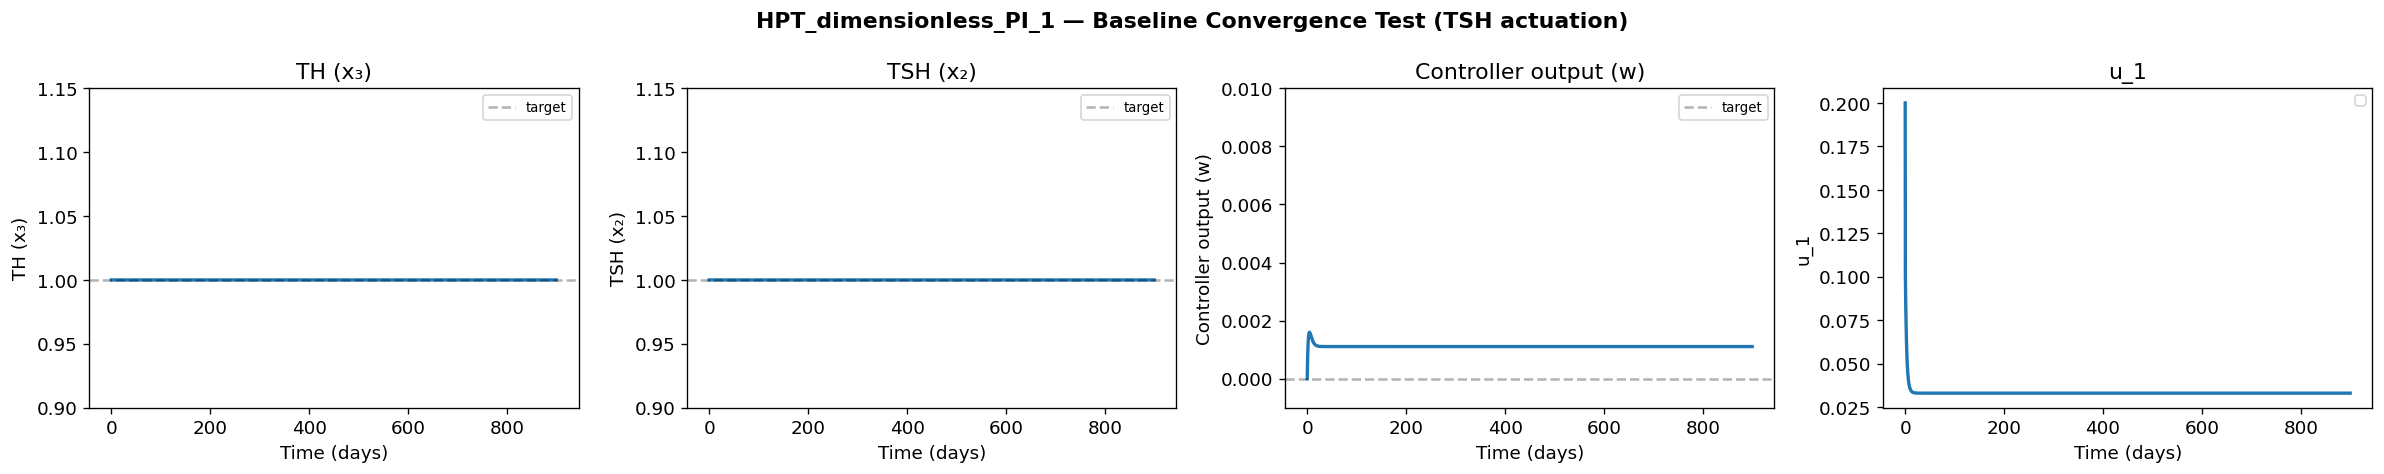

In [32]:
N_PTS = 5000
MODEL = 'HPT_dimensionless_PI_1'

overrides = {
    'AB_max': 0.0,
    'kT_max': 0.0,
    'kP_max': 0.0,
    't_on':   999999.0,
    't_off':  999999.0,
}
DEFAULT_PARAMS[MODEL].update(overrides)

# theta_1 is now a manual gain — not derived from a3
p = DEFAULT_PARAMS[MODEL]
p["theta_1"] = 0.01

defaults    = {k: float(v) for k, v in DEFAULT_PARAMS[MODEL].items()}
defaults_ic = {k: float(v) for k, v in DEFAULT_INITIAL_CONDITIONS[MODEL].items()}

# Verify — w_ss should be 0 at healthy baseline
u1_ss = defaults["alpha_1"] * defaults["ref"] / defaults["delta"]
w_ss  = defaults["theta_1"] * u1_ss / defaults["delta"]
print(f"theta_1: {defaults['theta_1']:.4f}")
print(f"u1_ss:   {u1_ss:.4f}")
print(f"w_ss:    {w_ss:.4f}  (target: 0.0 — no TSH supplement needed at healthy SS)")

# Baseline convergence test
res_baseline = runner.run_deterministic(
    MODEL, t_span=(0, 900), points=N_PTS,
    params=defaults, ic=defaults_ic
)

p = DEFAULT_PARAMS[MODEL]
print("=== HPT timescales ===")
print(f"TRH (x1):   {1/p['a1']:.1f} days")
print(f"TSH (x2):   {1/p['a2']:.1f} days")
print(f"TH  (x3):   {1/p['a3']:.1f} days")
print(f"T_mass:     {1/p['aT']:.1f} days")
print(f"P_mass:     {1/p['aP']:.1f} days")
print("\n=== Controller timescales ===")
print(f"u1/u2/w:    {1/p['delta']:.1f} days")
print(f"q1/q2:      {1/p['delta']:.1f} days")

t, s = res_baseline['time'], res_baseline['states']

print(f"\n=== Baseline final values ===")
print(f"x3:     {s['x3'][-1]:.4f}  (target: 1.0)")
print(f"x2:     {s['x2'][-1]:.4f}  (target: 1.0)")
print(f"w:      {s['w'][-1]:.4f}   (target: 0.0 — no supplement at healthy SS)")
print(f"T_mass: {s['T_mass'][-1]:.4f}  (target: 1.0)")
print(f"P_mass: {s['P_mass'][-1]:.4f}  (target: 1.0)")

equilibrated_ic = {k: float(s[k][-1]) for k in s}
print("\n=== Equilibrated ICs ===")
for k, v in equilibrated_ic.items():
    print(f"  {k}: {v:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
variables = [('x3', 'TH (x₃)'), ('x2', 'TSH (x₂)'), ('w', 'Controller output (w)'), ('u_1', 'u_1')]

for ax, (var, ylabel) in zip(axes, variables):
    ax.plot(t, s[var], lw=2)
    targets = {'x3': 1.0, 'x2': 1.0, 'w': 0.0}  # w target is now 0
    if var in targets:
        ax.axhline(targets[var], color='k', ls='--', alpha=0.3, label='target')
    
    if var in ('x3', 'x2'):
        ax.set_ylim(0.9, 1.15)
    elif var == 'w':
        ax.set_ylim(-0.001, 0.01)
        
    ax.set(xlabel='Time (days)', ylabel=ylabel, title=ylabel)
    ax.legend(fontsize=8)

plt.suptitle(f"{MODEL} — Baseline Convergence Test (TSH actuation)", fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Quick sanity check — run with AB_max=0 (no disease)
MODEL   = 'HPT_dimensionless_PI_1'
N_PTS   = 5000
defaults = {k: float(v) for k, v in DEFAULT_PARAMS["HPT_dimensionless_PI_1"].items()}
defaults_ic = {k: float(v) for k, v in DEFAULT_INITIAL_CONDITIONS["HPT_dimensionless_PI_1"].items()}

res_check = runner.run_deterministic(
    MODEL, t_span=(0, 500), points=N_PTS,
    params={**defaults, 'AB_max': 0.0, 'kT_max': 1.0, 'kP_max': 1.0,
            't_on': 999999.0, 't_off': 999999.0},
    ic=defaults_ic
)
s = res_check['states']
print(f"x3:     {s['x3'][-1]:.4f}")
print(f"x2:     {s['x2'][-1]:.4f}")
print(f"T_mass: {s['T_mass'][-1]:.4f}")
print(f"P_mass: {s['P_mass'][-1]:.4f}")
print(f"w:      {s['w'][-1]:.4f}")


import numpy as np
t_on = 600
k_ramp = 0.05
AB_max = 5.0
t_off = 700

AB_at_t0 = AB_max * (1/(1+np.exp(-k_ramp*(0-t_on)))) * (1 - 1/(1+np.exp(-k_ramp*(0-t_off))))
print(f"AB at t=0: {AB_at_t0:.6f}")

# Also check kT
kT_max = 1.0
kT_at_t0 = kT_max * (1/(1+np.exp(-k_ramp*(0-t_on))))
print(f"kT at t=0: {kT_at_t0:.6f}")

x3:     1.0000
x2:     1.0000
T_mass: 1.0000
P_mass: 0.9997
w:      0.0076
AB at t=0: 0.000000
kT at t=0: 0.000000


### Controlled, kT/kP persist — loop closes back to (1,1) because the controller remembers ref=1 — actually demonstrating this would be GREAT

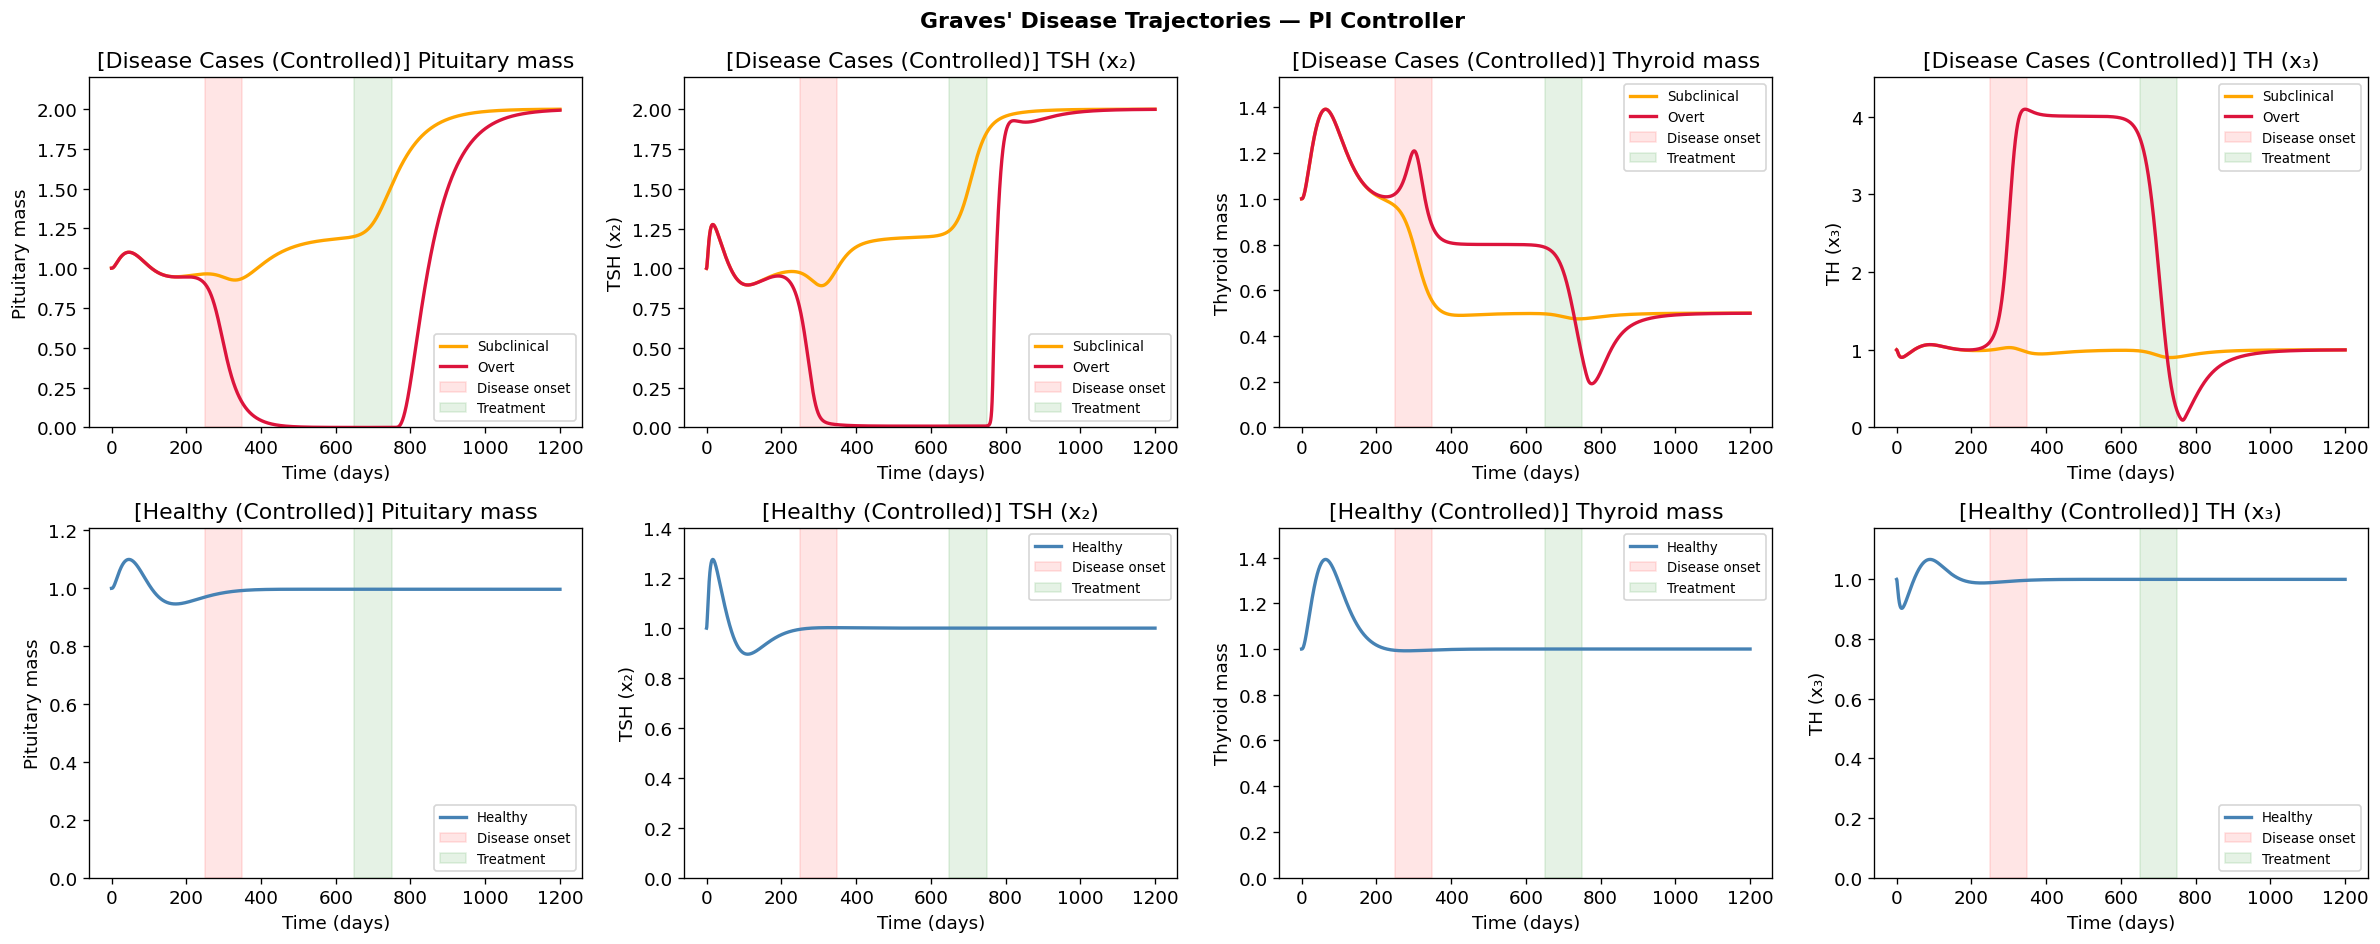

In [2]:
colors = {'Healthy': 'steelblue', 'Subclinical': 'orange', 'Overt': 'crimson'}
t_disease = 300.0
t_treat   = 700.0
T_SIM     = 1200.0
N_PTS     = 5000
MODEL     = 'HPT_dimensionless_PPI'  # fixed: was 'HPT_dimensionless_PPI_1'

defaults    = {k: float(v) for k, v in DEFAULT_PARAMS[MODEL].items()}
defaults_ic = {k: float(v) for k, v in DEFAULT_INITIAL_CONDITIONS[MODEL].items()}

scenarios = {
    "Healthy": {
        **defaults,
        "AB_max": 0.0, "kT_max": 0.0, "kP_max": 0.0,
        "t_on": t_disease, "t_off": t_treat,
    },
    "Subclinical": {
        **defaults,
        "AB_max": 0.8, "kT_max": 1.0, "kP_max": 0.0,
        "t_on": t_disease, "t_off": t_treat,
    },
    "Overt": {
        **defaults,
        "AB_max": 5.0, "kT_max": 1.0, "kP_max": 0.0,
        "t_on": t_disease, "t_off": t_treat,
    },
}

results_controlled = {
    label: runner.run_deterministic(
        MODEL, t_span=(0, T_SIM), points=N_PTS, params=params, ic=defaults_ic,
    )
    for label, params in scenarios.items()
}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
variables  = [('P_mass', 'Pituitary mass'), ('x2', 'TSH (x₂)'), ('T_mass', 'Thyroid mass'), ('x3', 'TH (x₃)')]
row_data   = [
    {k: v for k, v in results_controlled.items() if k != 'Healthy'},
    {'Healthy': results_controlled['Healthy']},
]
row_labels = ['Disease Cases (Controlled)', 'Healthy (Controlled)']

for row, (case_results, row_label) in enumerate(zip(row_data, row_labels)):
    for col, (ax, (var, ylabel)) in enumerate(zip(axes[row], variables)):
        for label, res in case_results.items():
            ax.plot(res['time'], res['states'][var], color=colors[label], lw=2, label=label)
        ax.axvspan(t_disease - 50, t_disease + 50, alpha=0.1, color='red',   label='Disease onset')
        ax.axvspan(t_treat   - 50, t_treat   + 50, alpha=0.1, color='green', label='Treatment')
        ax.set(xlabel='Time (days)', ylabel=ylabel, title=f'[{row_label}] {ylabel}')
        ax.legend(fontsize=8)
        vals = np.concatenate([r['states'][var] for r in case_results.values()])
        ax.set_ylim(0, vals.max() * 1.1)  # fixed: was axes[row][col], ax already in scope

plt.suptitle("Graves' Disease Trajectories — PI Controller", fontweight='bold')
plt.tight_layout()
plt.show()

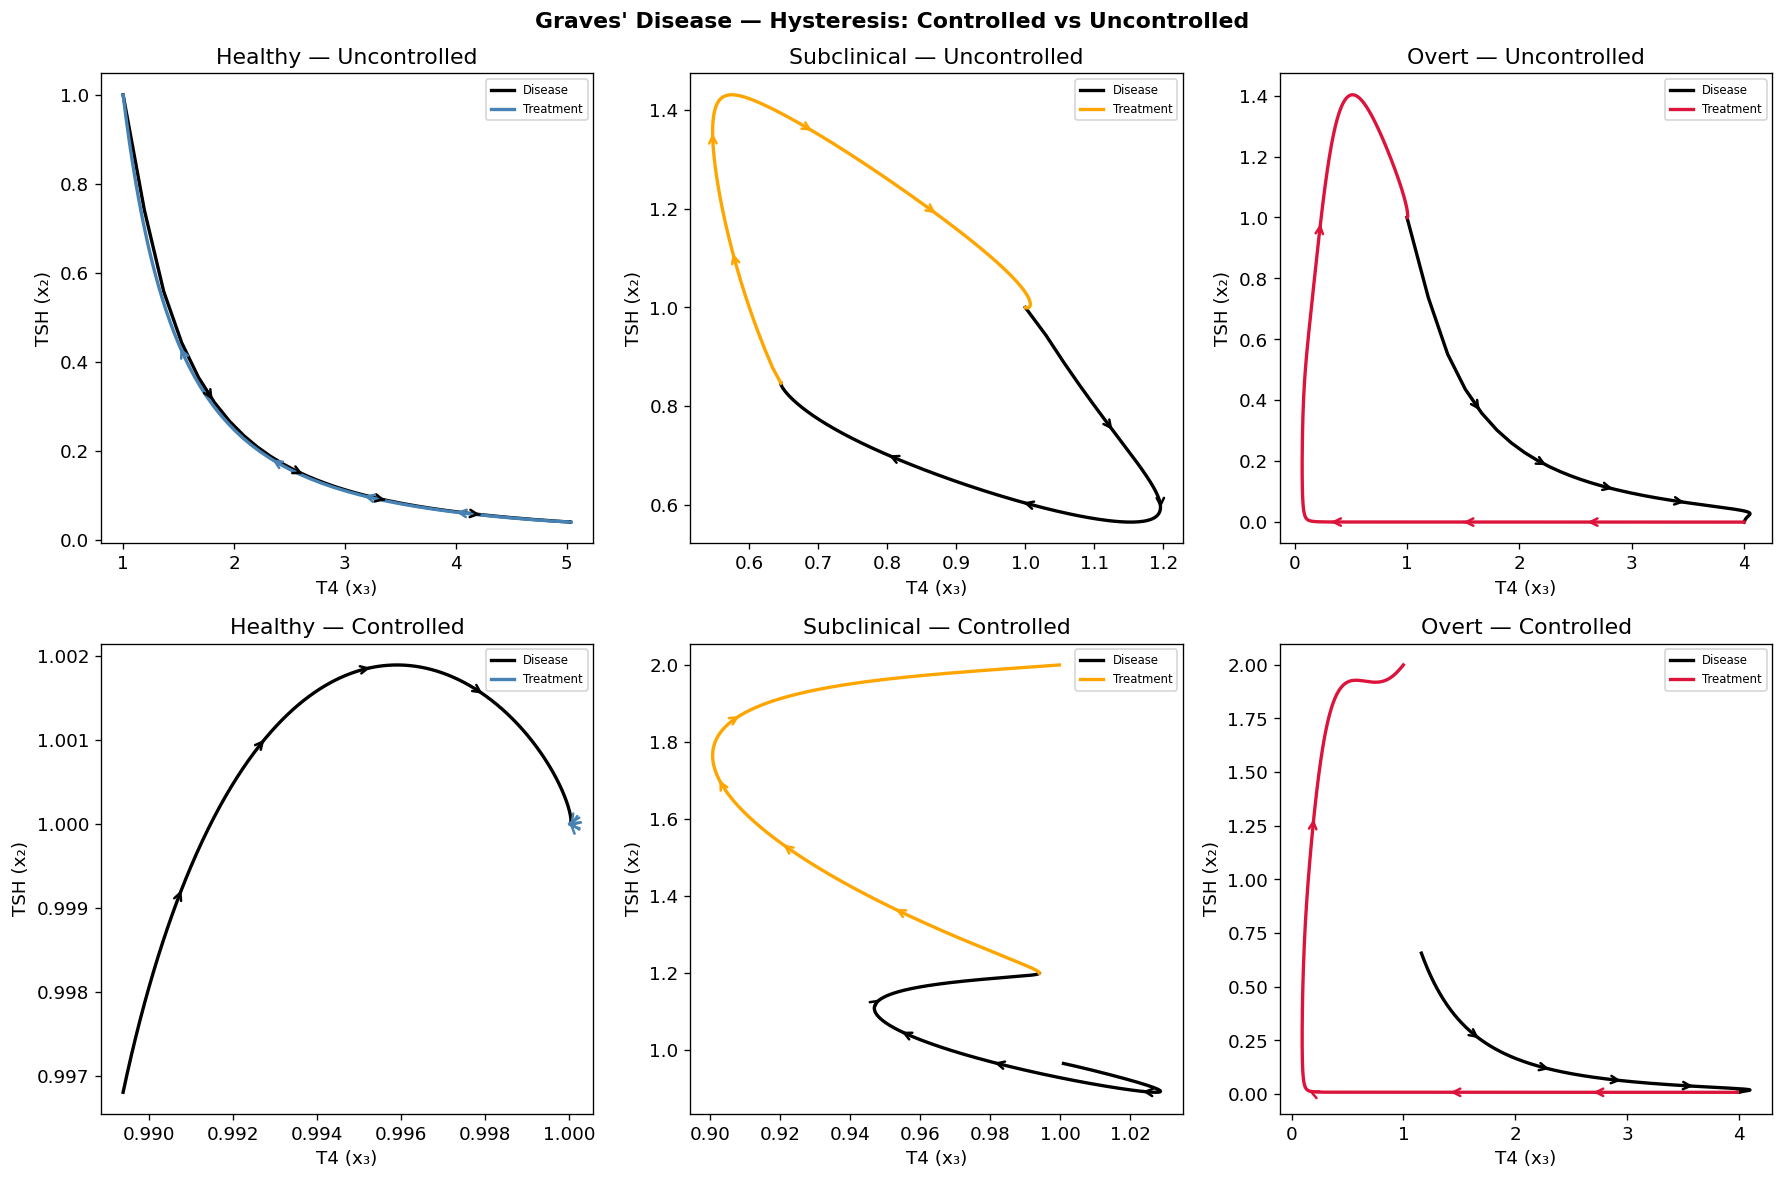

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, label in enumerate(['Healthy', 'Subclinical', 'Overt']):
    t_unc, s_unc = results[label]['time'],            results[label]['states']
    t_con, s_con = results_controlled[label]['time'], results_controlled[label]['states']

    disease_idx = (t_unc >= t_disease) & (t_unc < t_treat)
    treat_idx   = t_unc >= t_treat

    for row, (s, title_suffix) in enumerate([(s_unc, 'Uncontrolled'), (s_con, 'Controlled')]):
        ax = axes[row][col]
        ax.plot(s['x3'][disease_idx], s['x2'][disease_idx], 'k-',  lw=2, label='Disease')
        ax.plot(s['x3'][treat_idx],   s['x2'][treat_idx],   color=colors[label], lw=2, label='Treatment')
        add_arrows(ax, s['x3'][disease_idx], s['x2'][disease_idx], color='black')
        add_arrows(ax, s['x3'][treat_idx],   s['x2'][treat_idx],   color=colors[label])
        ax.set(xlabel='T4 (x₃)', ylabel='TSH (x₂)', title=f'{label} — {title_suffix}')
        ax.legend(fontsize=7)

plt.suptitle("Graves' Disease — Hysteresis: Controlled vs Uncontrolled", fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── Bifurcation: steady-state TH and TSH vs AB (recapitulates paper Fig 4B) ──
AB_vals  = np.linspace(0, 2.5, 60)
kT       = 0.3
ss_TH, ss_TSH, ss_P = [], [], []

for ab in AB_vals:
    res = runner.run_deterministic(MODEL, t_span=(0, 500), points=2000,
                                   params={'AB': ab, 'kT': kT})
    ss_TH.append(res['states']['x3'][-1])
    ss_TSH.append(res['states']['x2'][-1])
    ss_P.append(res['states']['P_mass'][-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(AB_vals, ss_TH,  'crimson', lw=2, label='TH (x3) SS')
axes[0].axvline(1 + kT, color='k', ls='--', alpha=0.6, label=f'Critical AB = 1+kT = {1+kT}')
axes[0].axhline(1.0, color='gray', ls=':', alpha=0.5)
axes[0].set(xlabel='AB (antibody level)', ylabel='Steady-state TH', title='TH vs AB')
axes[0].legend()

axes[1].plot(AB_vals, ss_TSH, 'navy', lw=2, label='TSH (x2) SS')
axes[1].plot(AB_vals, ss_P,   'darkorange', lw=1.5, ls='--', label='Pituitary mass (P) SS')
axes[1].axvline(1 + kT, color='k', ls='--', alpha=0.6, label=f'Critical AB = {1+kT}')
axes[1].set(xlabel='AB (antibody level)', ylabel='Steady-state value', title='TSH & Pituitary vs AB')
axes[1].legend()

plt.suptitle("Figure 3: Graves' Bifurcation — Transcritical at AB = 1 + kT", fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Transcritical bifurcation point: AB = 1 + kT = {1 + kT:.2f}')
print('  Below: TSH compensates, TH stable (subclinical hyperthyroidism)')
print('  Above: Pituitary collapses, TH rises (overt hyperthyroidism)')

ValueError: Unknown parameters for model 'HPT_dimensionless_PI_1': {'AB'}

## 3. Hashimoto's Thyroiditis
**Mechanism:** Progressive autoimmune destruction of thyrocytes (delta_H > 0), reducing functional thyroid mass T_mass over time.

**Expected dynamics:**
- T_mass declines → TH falls → pituitary grows (P_mass ↑) → TSH rises to compensate
- With infinite carrying capacity (kP=0): perfect adaptation — TH eventually restored
- With finite carrying capacity (kP > 0): imperfect adaptation — TH remains low (hypothyroidism)

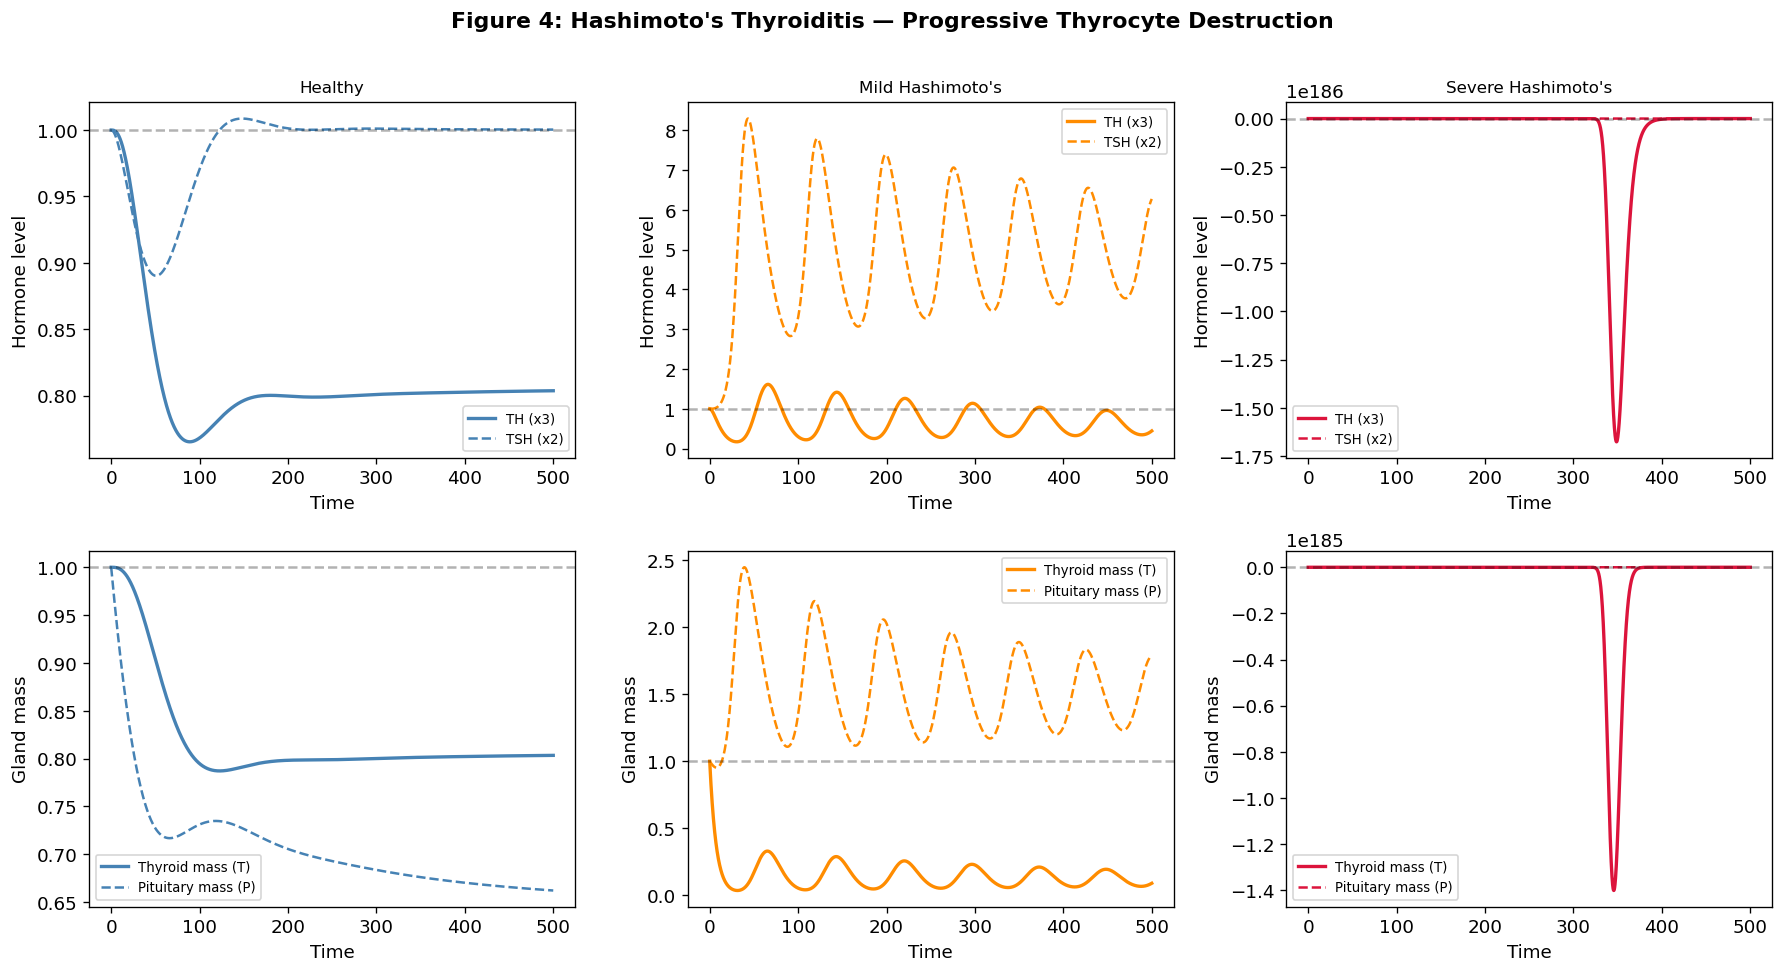

In [ ]:
hashimoto_scenarios = {
    'Healthy':                    {'kP': 0.3},
    'Mild Hashimoto\'s':          {'aT': 1/6, 'kP': 0.3},
    'Severe Hashimoto\'s':        {'aT': 0.5, 'kP': 0.3},
}

hashimoto_hysteresis = [
    # Phase 1: disease — increase thyrocyte removal rate
    {'time': 0,   'type': 'parameter', 'param': 'aT',  'value': DEFAULT_PARAMS['aT'] * 5.0},
    # Phase 2: treatment — levothyroxine supplement
    {'time': 200, 'type': 'parameter', 'param': 'B30', 'value': 0.5},
]


T_HASH = 500
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['steelblue', 'darkorange', 'crimson']

for col, (label, p), color in zip(range(3), hashimoto_scenarios.items(), colors):
    res = runner.run_deterministic(MODEL, t_span=(0, T_HASH), points=5000, params=p)
    t, s = res['time'], res['states']
    
    axes[0, col].plot(t, s['x3'], color=color, lw=2, label='TH (x3)')
    axes[0, col].plot(t, s['x2'], color=color, lw=1.5, ls='--', label='TSH (x2)')
    axes[0, col].axhline(1.0, color='k', ls='--', alpha=0.3)
    axes[0, col].set_title(label, fontsize=10)
    axes[0, col].set(xlabel='Time', ylabel='Hormone level')
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(t, s['T_mass'], color=color, lw=2, label='Thyroid mass (T)')
    axes[1, col].plot(t, s['P_mass'], color=color, lw=1.5, ls='--', label='Pituitary mass (P)')
    axes[1, col].axhline(1.0, color='k', ls='--', alpha=0.3)
    axes[1, col].set(xlabel='Time', ylabel='Gland mass')
    axes[1, col].legend(fontsize=8)

plt.suptitle("Figure 4: Hashimoto's Thyroiditis — Progressive Thyrocyte Destruction",
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Levothyroxine Treatment for Hashimoto's
External thyroid hormone supply (B30 > 0) simulates levothyroxine supplementation. 
We use `run_with_perturbations` to apply the treatment partway through the disease course.

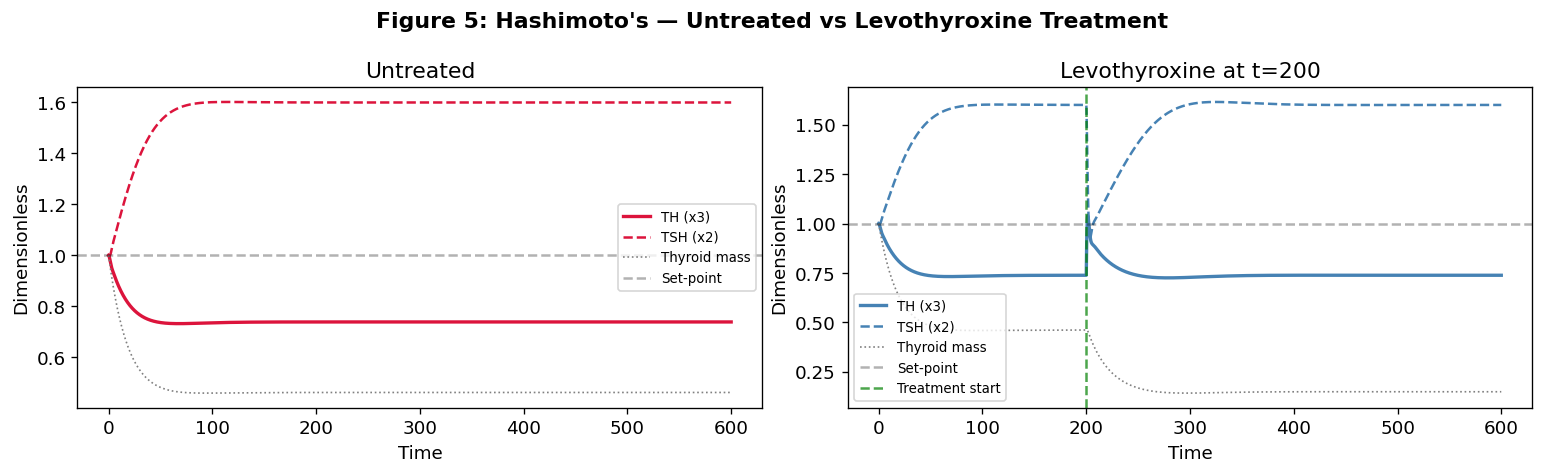

In [ ]:
T_TREAT = 600

# Untreated severe Hashimoto's
untreated = runner.run_deterministic(
    MODEL, t_span=(0, T_TREAT), points=6000,
    params={'delta_H': 0.03, 'kP': 0.3}
)

# Treated: disease starts at t=0, levothyroxine introduced at t=200
treated = runner.run_with_perturbations(
    MODEL,
    t_span=(0, T_TREAT),
    points=6000,
    params={'delta_H': 0.03, 'kP': 0.3},
    perturbations=[
        {'time': 200, 'type': 'parameter', 'param': 'B30', 'value': 0.5}
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, res, label, color in [
    (axes[0], untreated, 'Untreated', 'crimson'),
    (axes[1], treated,   'Levothyroxine at t=200', 'steelblue'),
]:
    t, s = res['time'], res['states']
    ax.plot(t, s['x3'], color=color, lw=2, label='TH (x3)')
    ax.plot(t, s['x2'], color=color, lw=1.5, ls='--', label='TSH (x2)')
    ax.plot(t, s['T_mass'], color='gray', lw=1, ls=':', label='Thyroid mass')
    ax.axhline(1.0, color='k', ls='--', alpha=0.3, label='Set-point')
    if 'perturbation_times' in res:
        for pt in res['perturbation_times']:
            ax.axvline(pt, color='green', ls='--', alpha=0.7, label='Treatment start')
    ax.set_title(label)
    ax.set(xlabel='Time', ylabel='Dimensionless')
    ax.legend(fontsize=8)

plt.suptitle("Figure 5: Hashimoto's — Untreated vs Levothyroxine Treatment", fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Connecting a Biomolecular PI Controller

**Concept:** The HPT axis itself functions as a PI controller for TH. We can draw a parallel to the abstract `PI_1` biomolecular controller from our codebase.

Here we demonstrate the analogy by showing that increasing the integral gain of the pituitary (via faster `aP` dynamics) improves TH restoration after thyrocyte destruction — mirroring how a PI controller with higher gain corrects steady-state error faster.

This is equivalent to pharmacologically enhancing pituitary responsiveness.

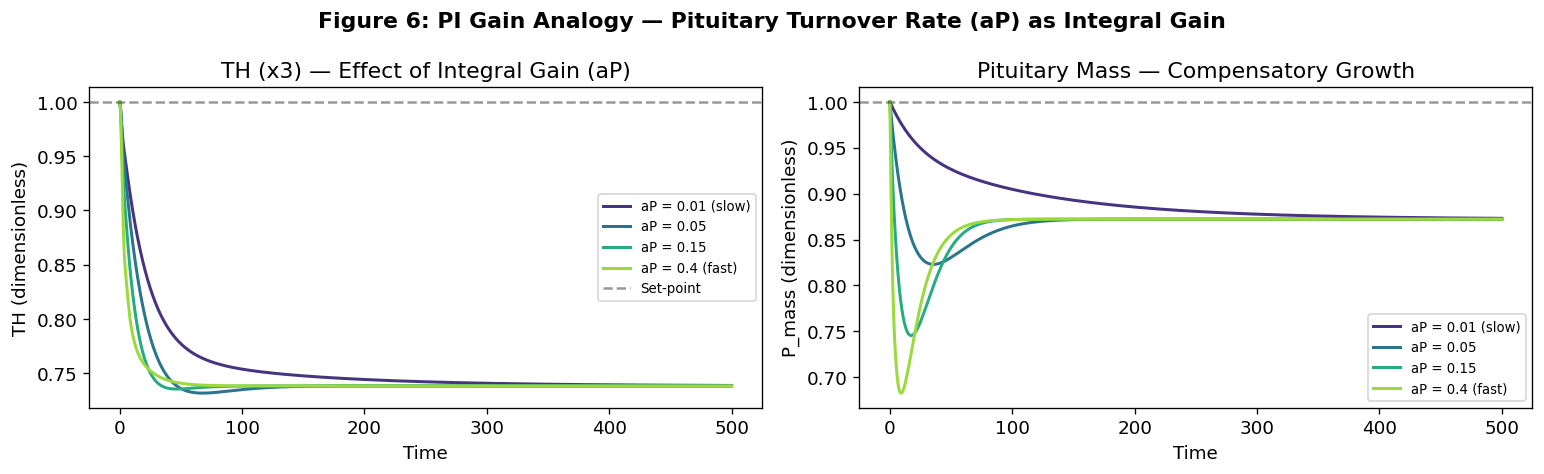

Interpretation:
  Higher aP → pituitary adapts faster → TH restored more quickly
  This mirrors increasing ki (integral gain) in a PI controller
  The HPT axis pituitary IS a biological integral controller for TH


In [ ]:
# Sweep pituitary gain (aP) — faster aP = stronger integral action = better TH recovery
aP_vals = [0.01, 0.05, 0.15, 0.4]
labels  = [f'aP = {v} (slow)' if v == min(aP_vals) else
           f'aP = {v} (fast)' if v == max(aP_vals) else
           f'aP = {v}' for v in aP_vals]
colors  = plt.cm.viridis(np.linspace(0.15, 0.85, len(aP_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ap, label, color in zip(aP_vals, labels, colors):
    res = runner.run_deterministic(
        MODEL, t_span=(0, 500), points=5000,
        params={'delta_H': 0.03, 'kP': 0.3, 'aP': ap}
    )
    t, s = res['time'], res['states']
    axes[0].plot(t, s['x3'], color=color, lw=1.8, label=label)
    axes[1].plot(t, s['P_mass'], color=color, lw=1.8, label=label)

axes[0].axhline(1.0, color='k', ls='--', alpha=0.4, label='Set-point')
axes[0].set(title='TH (x3) — Effect of Integral Gain (aP)',
            xlabel='Time', ylabel='TH (dimensionless)')
axes[0].legend(fontsize=8)

axes[1].axhline(1.0, color='k', ls='--', alpha=0.4)
axes[1].set(title='Pituitary Mass — Compensatory Growth',
            xlabel='Time', ylabel='P_mass (dimensionless)')
axes[1].legend(fontsize=8)

plt.suptitle('Figure 6: PI Gain Analogy — Pituitary Turnover Rate (aP) as Integral Gain',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Higher aP → pituitary adapts faster → TH restored more quickly')
print('  This mirrors increasing ki (integral gain) in a PI controller')
print('  The HPT axis pituitary IS a biological integral controller for TH')

## 6. Side-by-Side Disease Comparison
A summary figure directly comparing the two disease states against the healthy baseline.

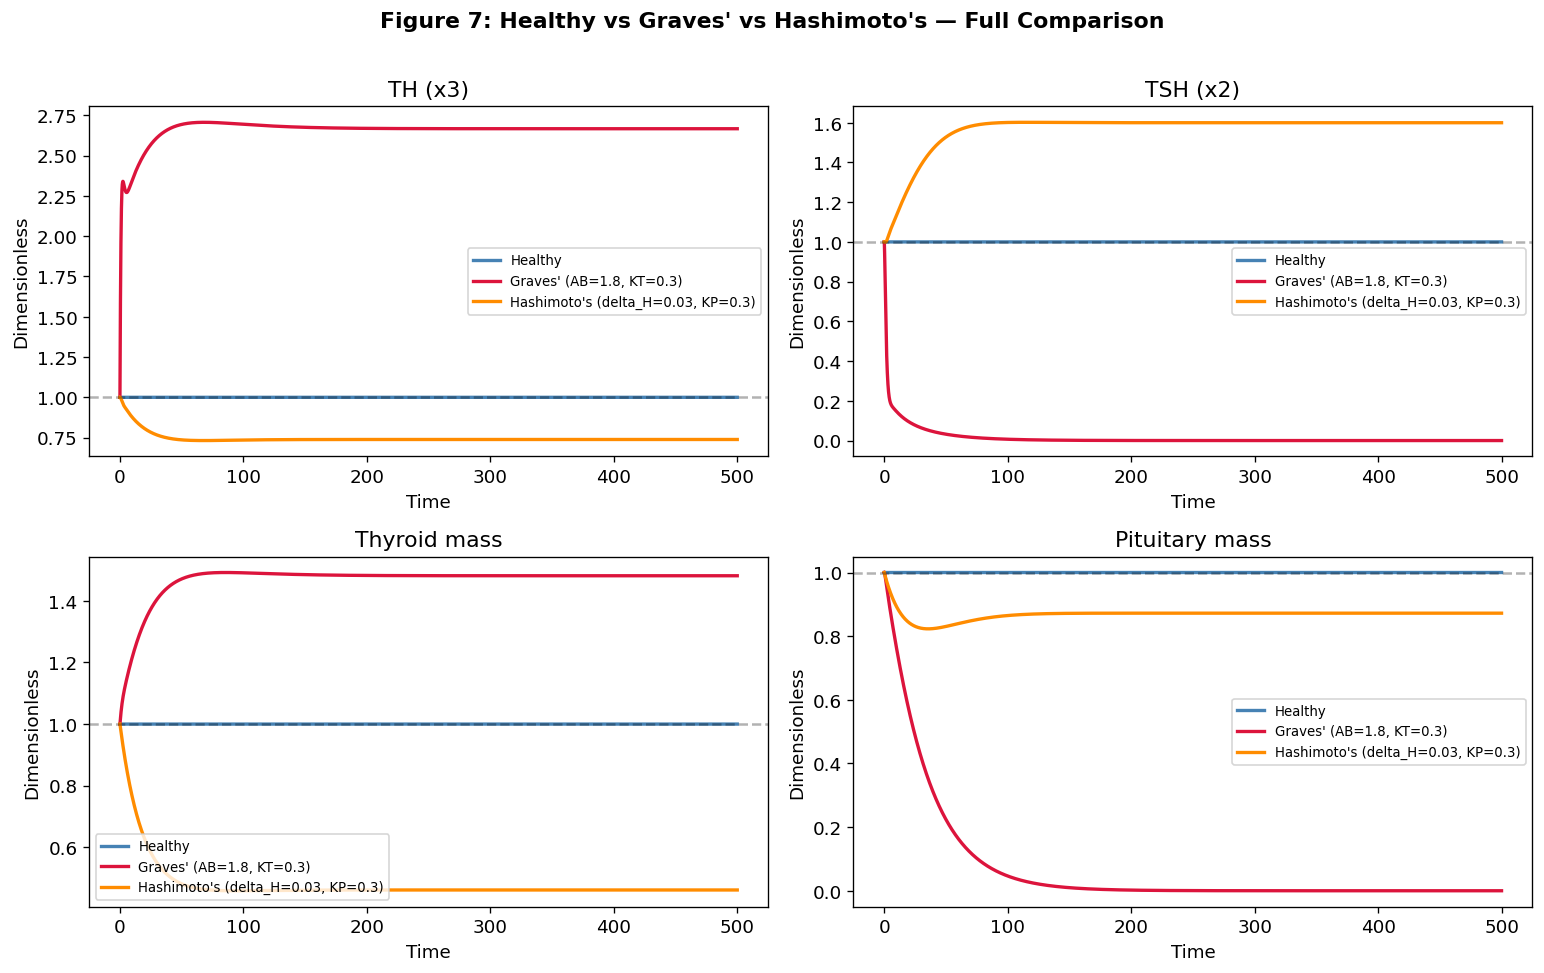

In [ ]:
scenarios = {
    'Healthy':       {},
    "Graves' (AB=1.8, kT=0.3)": {'AB': 1.8, 'kT': 0.3},
    "Hashimoto's (delta_H=0.03, kP=0.3)": {'delta_H': 0.03, 'kP': 0.3},
}
colors = ['steelblue', 'crimson', 'darkorange']
vars_to_plot = [('x3', 'TH (x3)'), ('x2', 'TSH (x2)'),
                ('T_mass', 'Thyroid mass'), ('P_mass', 'Pituitary mass')]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (var, var_label) in zip(axes, vars_to_plot):
    for (label, p), color in zip(scenarios.items(), colors):
        res = runner.run_deterministic(MODEL, t_span=(0, 500), points=5000, params=p)
        ax.plot(res['time'], res['states'][var], color=color, lw=2, label=label)
    ax.axhline(1.0, color='k', ls='--', alpha=0.3)
    ax.set(title=var_label, xlabel='Time', ylabel='Dimensionless')
    ax.legend(fontsize=8)

plt.suptitle("Figure 7: Healthy vs Graves' vs Hashimoto's — Full Comparison",
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Summary

| Disease | Parameter | Mechanism | TH | TSH | Gland masses |
|---|---|---|---|---|---|
| Healthy | — | — | ~1 | ~1 | T=P=1 |
| Graves' (subclinical) | AB < 1+kT | Antibodies stimulate thyroid | ~1 | ↓ | P↓, T↑ |
| Graves' (overt) | AB > 1+kT | Pituitary collapses | ↑↑ | →0 | P→0, T↑↑ |
| Hashimoto's | delta_H > 0 | Thyrocyte destruction | ↓ | ↑ | T↓, P↑ |
| Hashimoto's + Levo | delta_H > 0, B30 > 0 | External TH supply | restored | ↓ | P normalizes |

**PI Controller Analogy:** The pituitary thyrotroph mass acts as a **biological integrator** — it accumulates error in TH and drives TSH until TH returns to set-point. This is exactly the role of the integral term in the biomolecular PI controllers (`PI_1`, `PI_2`) in our codebase. The `aP` parameter is analogous to the integral gain `ki`.